# Plot 10-year ACE2 simulation results of KW-TC statistics (Fig. 2)
Mu-Ting Chien
2025.12.7

In [3]:
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from scipy.stats import binom
import os 
import cmaps

In [4]:
DIR                    = '/barnes-engr-scratch1/c832572266/'
file_dir_obs_ace2      = DIR + 'data_output/ace2/obs_compare_with_ace2/'
file_dir_ace2          = DIR + 'data_output/ace2/ace2_output/10yr/'
file_dir_ace2_100yr    = DIR + 'data_output/ace2/ace2_output/repeat_2001-2010/'
expname_list           = list(['ace2','era5'])
fig_dir                = DIR + 'figure/paper2_fig/revision2/' # previous figures are located outside of revision1
os.makedirs(fig_dir, exist_ok=True)
fig_dir_supplement = fig_dir + 'supplement/'
os.makedirs(fig_dir_supplement, exist_ok=True)
sub_dir = list(['2001','2002','2003','2004','2005','2006','2007','2008','2009','2010'])
nsub    = np.size(sub_dir)

In [11]:
hr_bin_daily = np.arange(-8.5, 9.5, 1)

In [6]:
######################
# Load ACE2 (100 yr)
######################

# Aggregate dhr for each basin for 100 years
i0 = 0
i1 = 0
i2 = 0
i3 = 0
i4 = 0
i5 = 0

for first_time_exe in range(1, -1, -1):

    nsub = np.size(sub_dir)
    for isub in range(0, nsub):
        
        # Load ACE2
        yrname = sub_dir[isub]
        data = np.load(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_lag_kwcrest_hr_10SN_'+yrname+'_basin.npz')
        dhr_basin0_ace2_real = data['dhr_ace2_basin0']
        dhr_basin1_ace2_real = data['dhr_ace2_basin1']
        dhr_basin2_ace2_real = data['dhr_ace2_basin2']
        dhr_basin3_ace2_real = data['dhr_ace2_basin3']
        dhr_basin4_ace2_real = data['dhr_ace2_basin4']
        dhr_basin5_ace2_real = data['dhr_ace2_basin5']
        basin_list           = data['basin_list']
        nbasin               = np.size(basin_list)

        if first_time_exe == 1:
            if isub == 0:
                size_basin_all = np.empty([nsub, nbasin])
            for ibasin in range(0, nbasin):
                tmp = globals()['dhr_basin'+str(ibasin)+'_ace2_real']
                size_basin_all[isub,ibasin] = np.size(tmp)
        else:
            if isub == 0:
                dhr_basin0_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,0],0)) ])
                dhr_basin1_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,1],0)) ])
                dhr_basin2_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,2],0)) ])
                dhr_basin3_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,3],0)) ])
                dhr_basin4_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,4],0)) ])
                dhr_basin5_ace2_100yr_real = np.empty([ int(np.sum(size_basin_all[:,5],0)) ])

            dhr_basin0_ace2_100yr_real[i0:i0+ int(size_basin_all[isub,0]) ] = dhr_basin0_ace2_real
            dhr_basin1_ace2_100yr_real[i1:i1+ int(size_basin_all[isub,1]) ] = dhr_basin1_ace2_real
            dhr_basin2_ace2_100yr_real[i2:i2+ int(size_basin_all[isub,2]) ] = dhr_basin2_ace2_real
            dhr_basin3_ace2_100yr_real[i3:i3+ int(size_basin_all[isub,3]) ] = dhr_basin3_ace2_real
            dhr_basin4_ace2_100yr_real[i4:i4+ int(size_basin_all[isub,4]) ] = dhr_basin4_ace2_real
            dhr_basin5_ace2_100yr_real[i5:i5+ int(size_basin_all[isub,5]) ] = dhr_basin5_ace2_real

            i0 = i0 + int( size_basin_all[isub,0] )
            i1 = i1 + int( size_basin_all[isub,1] )
            i2 = i2 + int( size_basin_all[isub,2] )
            i3 = i3 + int( size_basin_all[isub,3] )
            i4 = i4 + int( size_basin_all[isub,4] )
            i5 = i5 + int( size_basin_all[isub,5] )

In [7]:
######################
# Load ACE2 (10 yr) : only load the first member of 2001-2010
######################

# Aggregate dhr for each basin for 100 years
i0 = 0
i1 = 0
i2 = 0
i3 = 0
i4 = 0
i5 = 0

for first_time_exe in range(1, -1, -1):

    nsub = np.size(sub_dir)
    for isub in range(0, nsub):
        
        # Load ACE2
        yrname = sub_dir[isub]
        data = np.load(file_dir_ace2_100yr+'TC_genesis_30SN/TCgenesis_lag_kwcrest_hr_10SN_'+yrname+'_basin.npz')

        ntmp                 = np.size(data['dhr_ace2_basin0'])
        dhr_basin0_ace2_real = data['dhr_ace2_basin0'][0:int(np.floor(ntmp/10))]
        ntmp                 = np.size(data['dhr_ace2_basin1'])
        dhr_basin1_ace2_real = data['dhr_ace2_basin1'][0:int(np.floor(ntmp/10))]
        ntmp                 = np.size(data['dhr_ace2_basin2'])
        dhr_basin2_ace2_real = data['dhr_ace2_basin2'][0:int(np.floor(ntmp/10))]
        ntmp                 = np.size(data['dhr_ace2_basin3'])
        dhr_basin3_ace2_real = data['dhr_ace2_basin3'][0:int(np.floor(ntmp/10))]
        ntmp                 = np.size(data['dhr_ace2_basin4'])
        dhr_basin4_ace2_real = data['dhr_ace2_basin4'][0:int(np.floor(ntmp/10))]
        ntmp                 = np.size(data['dhr_ace2_basin5'])
        dhr_basin5_ace2_real = data['dhr_ace2_basin5'][0:int(np.floor(ntmp/10))]

        if first_time_exe == 1:
            if isub == 0:
                size_basin_all = np.empty([nsub, nbasin])
            for ibasin in range(0, nbasin):
                tmp = globals()['dhr_basin'+str(ibasin)+'_ace2_real']
                size_basin_all[isub,ibasin] = np.size(tmp)
        else:
            if isub == 0:
                dhr_basin0_ace2_10yr_real = np.empty([ int(np.sum(size_basin_all[:,0],0)) ])
                dhr_basin1_ace2_10yr_real = np.empty([ int(np.sum(size_basin_all[:,1],0)) ])
                dhr_basin2_ace2_10yr_real = np.empty([ int(np.sum(size_basin_all[:,2],0)) ])
                dhr_basin3_ace2_10yr_real = np.empty([ int(np.sum(size_basin_all[:,3],0)) ])
                dhr_basin4_ace2_10yr_real = np.empty([ int(np.sum(size_basin_all[:,4],0)) ])
                dhr_basin5_ace2_10yr_real = np.empty([ int(np.sum(size_basin_all[:,5],0)) ])

            dhr_basin0_ace2_10yr_real[i0:i0+ int(size_basin_all[isub,0]) ] = dhr_basin0_ace2_real
            dhr_basin1_ace2_10yr_real[i1:i1+ int(size_basin_all[isub,1]) ] = dhr_basin1_ace2_real
            dhr_basin2_ace2_10yr_real[i2:i2+ int(size_basin_all[isub,2]) ] = dhr_basin2_ace2_real
            dhr_basin3_ace2_10yr_real[i3:i3+ int(size_basin_all[isub,3]) ] = dhr_basin3_ace2_real
            dhr_basin4_ace2_10yr_real[i4:i4+ int(size_basin_all[isub,4]) ] = dhr_basin4_ace2_real
            dhr_basin5_ace2_10yr_real[i5:i5+ int(size_basin_all[isub,5]) ] = dhr_basin5_ace2_real

            i0 = i0 + int( size_basin_all[isub,0] )
            i1 = i1 + int( size_basin_all[isub,1] )
            i2 = i2 + int( size_basin_all[isub,2] )
            i3 = i3 + int( size_basin_all[isub,3] )
            i4 = i4 + int( size_basin_all[isub,4] )
            i5 = i5 + int( size_basin_all[isub,5] )

In [8]:
#####################################
# Load real statistics from observation
##################################
expname_list  = list(['ace2','era5'])
iexp = 1
data = np.load(file_dir_obs_ace2+'TCgenesis_lag_kwcrest_hr_10SN_'+expname_list[iexp]+'_basin.npz')
dhr_basin0_obs_real = data['dhr_basin0']
dhr_basin1_obs_real = data['dhr_basin1']
dhr_basin2_obs_real = data['dhr_basin2']
dhr_basin3_obs_real = data['dhr_basin3']
dhr_basin4_obs_real = data['dhr_basin4']
dhr_basin5_obs_real = data['dhr_basin5']

In [9]:
#################################
# Load random distribution
#################################
data     = np.load(file_dir_ace2_100yr + 'lag_hrs_TCgenesis_near_KWpeak_random_selection_basin_obs_ace2.npz')
dhr_rand = data['dhr_rand']

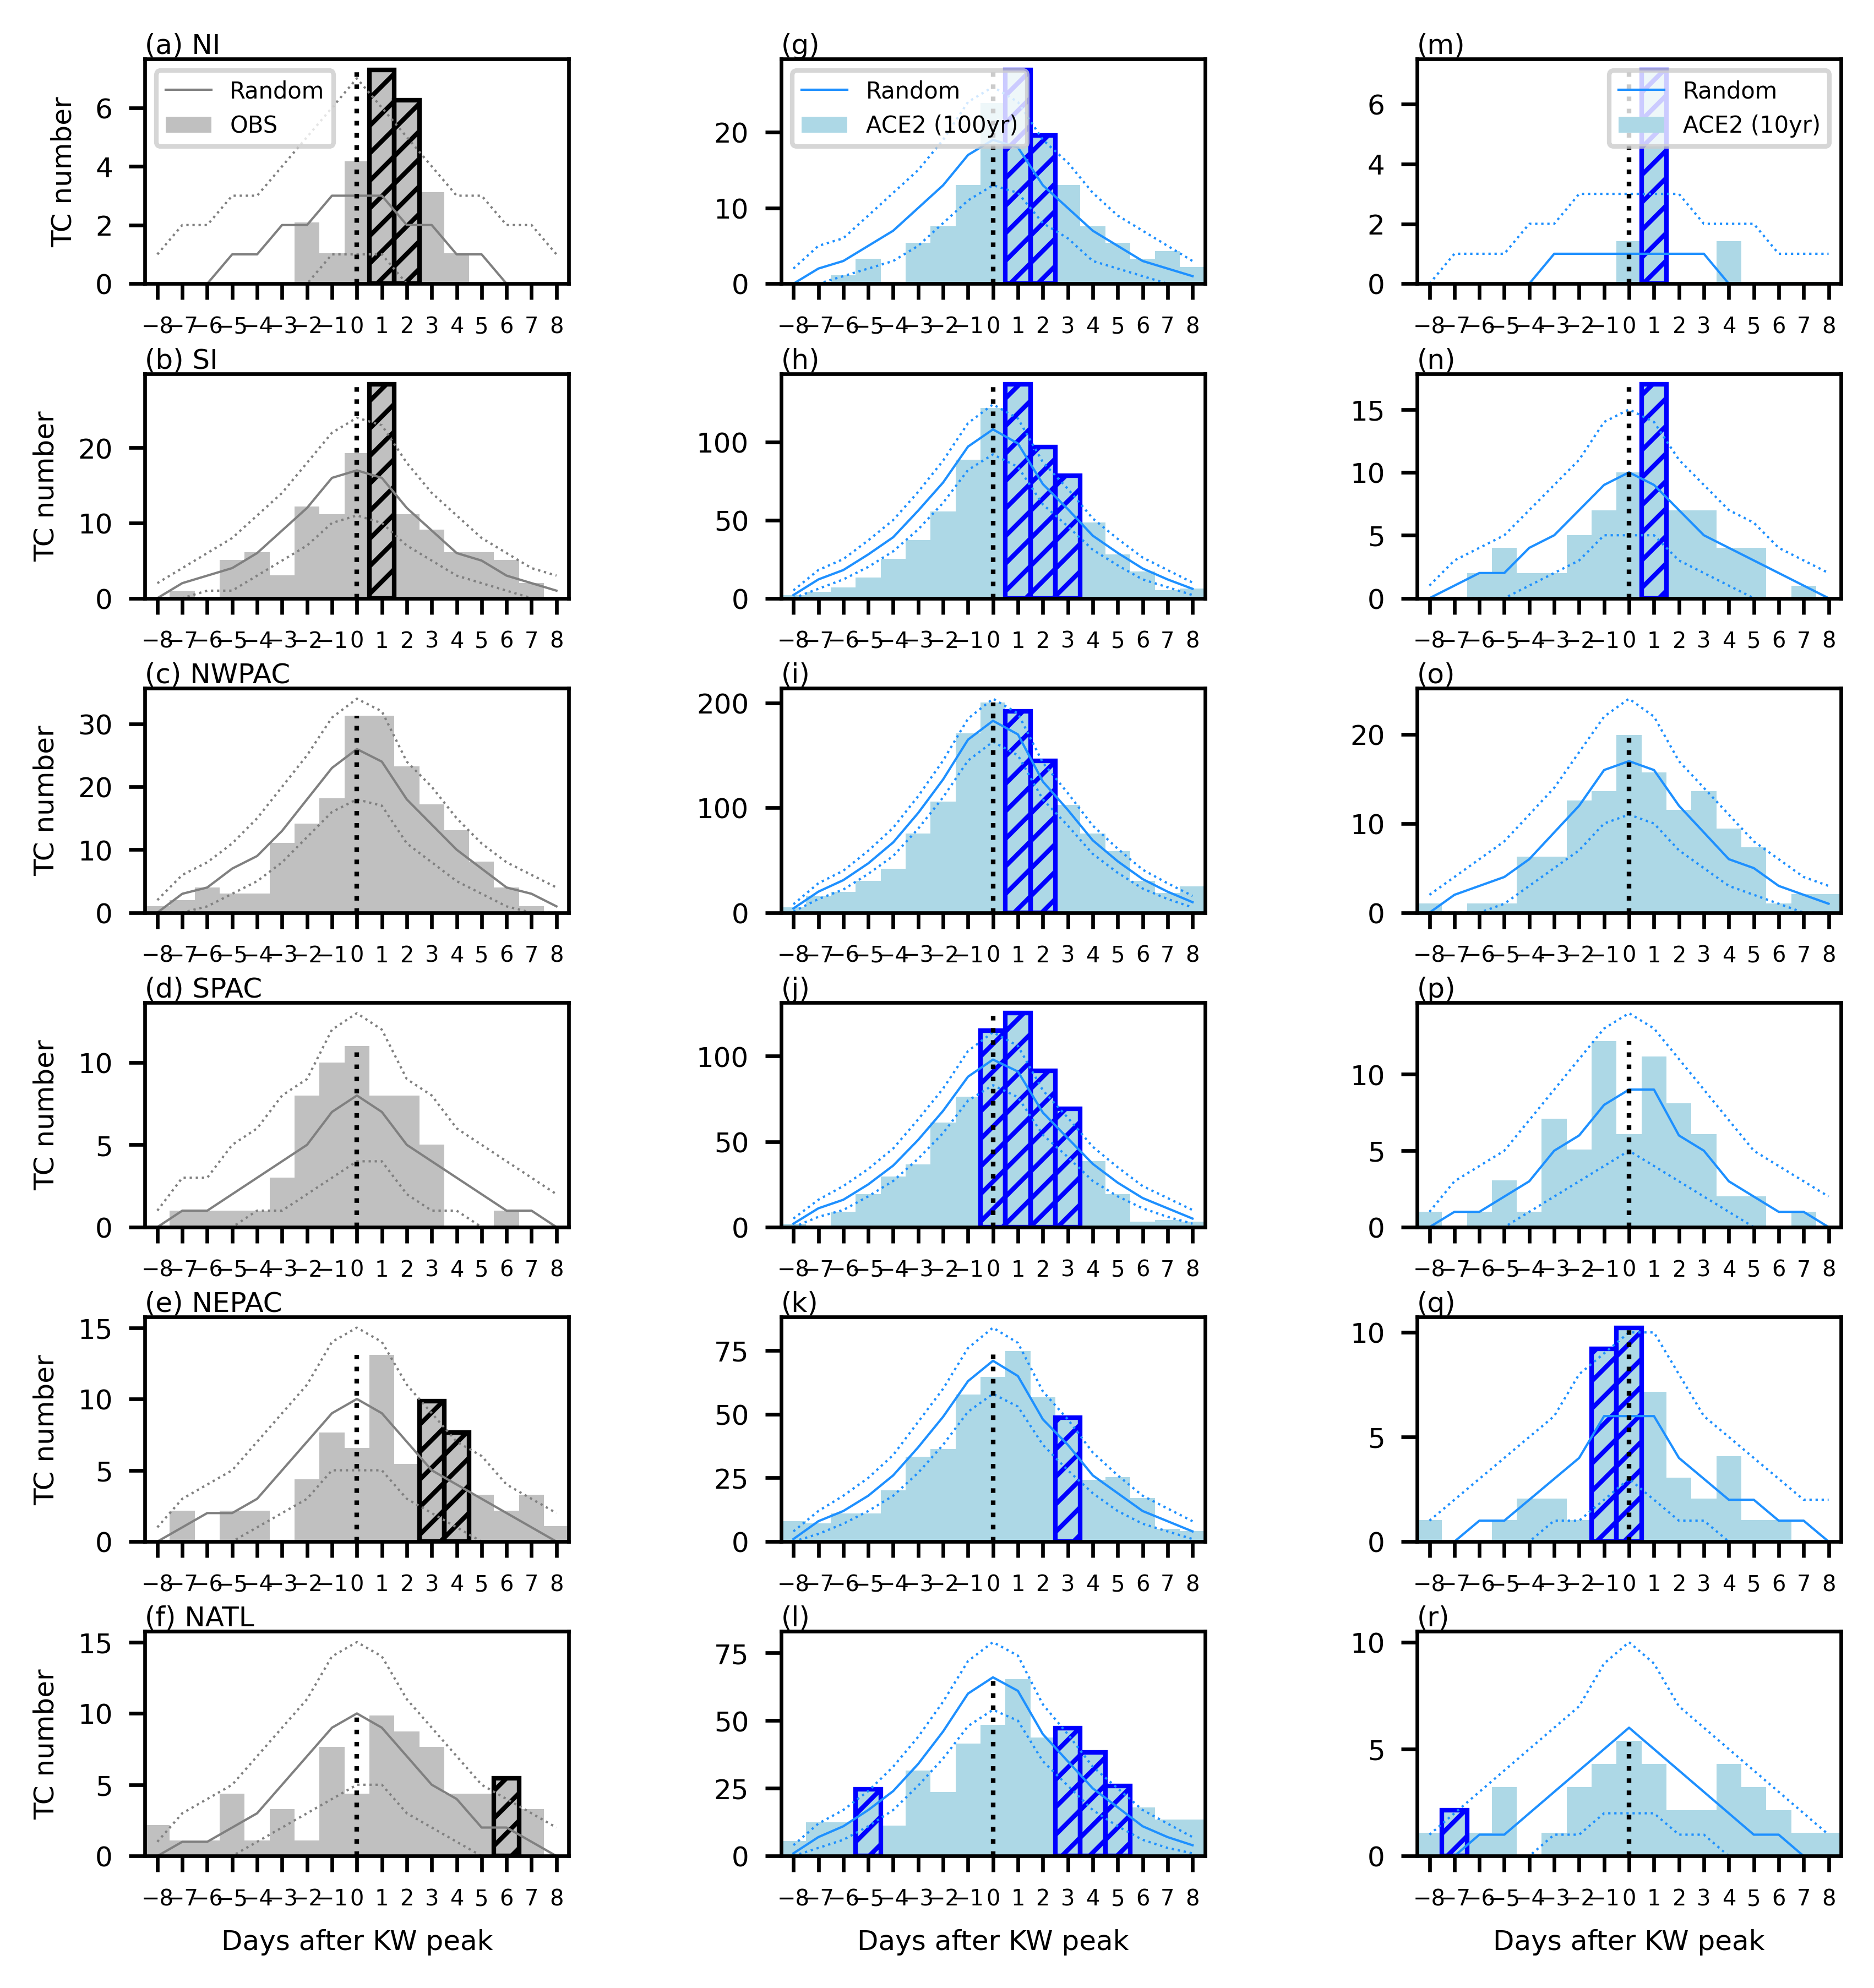

In [15]:
nbasin = 6
obs_only = 0 #0 or 1
ace2_only = 1 # 0 or 1
obs_only_list = list(['','_only_obs'])
ace2_only_list = list(['','_only_ace2'])
hr_list = list(['','_12h'])
#ibasin_real = np.array([0, 1, 2, 4, 5, 3])
ibasin_real = np.array([0, 4, 1, 5, 2, 3])
title_list = list(['(a)','(g)','(m)','(b)','(h)','(n)',\
                    '(c)','(i)','(o)','(d)','(j)','(p)',\
                    '(e)','(k)','(q)','(f)','(l)','(r)'])

font = 6

fig_name = 'Fig.S5_KW_TCgenesis_laghr_histogram_obs-ace100-ace10.png'
fig = plt.subplots(6,3,figsize=(6.5, 8),dpi=600)
plt.subplots_adjust(left=0.2,right=0.99,top=0.88,bottom=0.2, hspace=0.4, wspace=0.5)
plt.rcParams.update({'font.size': 6})
zero = np.array([0,0])
ifig_list = np.array([1,4,7,10,13,16,\
        2,5,8,11,14,17,\
            3,6,9,12,15,18])
k = 0
for icol in range(0, 3):
    for ibasin in range(0, nbasin):
        ifig = ifig_list[k]-1
        plt.subplot(6, 3, ifig_list[k])

        dhr_tmp_ace2_real      = globals()['dhr_basin'+str(ibasin_real[ibasin])+'_ace2_100yr_real']
        dhr_tmp_ace2_real_10yr = globals()['dhr_basin'+str(ibasin_real[ibasin])+'_ace2_10yr_real']
        dhr_tmp_era5_real      = globals()['dhr_basin'+str(ibasin_real[ibasin])+'_obs_real']
            
        dhr_tmp_ace2_rand = globals()['dhr_rand']
        dhr_tmp_era5_rand = globals()['dhr_rand']


        # Create the null hypothesis
        counts, bin_edges = np.histogram(dhr_tmp_ace2_rand/24, hr_bin_daily)
        p_ace2_rand = counts/np.nansum(counts)
        #
        counts, bin_edges = np.histogram(dhr_tmp_ace2_rand/24, hr_bin_daily)
        p_ace2_rand_10yr = counts/np.nansum(counts)
        #
        counts, bin_edges = np.histogram(dhr_tmp_era5_rand/24, hr_bin_daily)
        p_obs_rand = counts/np.nansum(counts)

        bin_center = (bin_edges[1:]+bin_edges[:-1])/2
            
        # Count TC number in total
        n_ace2      = np.size(dhr_tmp_ace2_real)
        n_ace2_10yr = np.size(dhr_tmp_ace2_real_10yr)
        n_obs       = np.size(dhr_tmp_era5_real)

        # Find the 95th percentile for each bin (start here!!!)
        target_cdf = 0.95 #0.9 #0.95
        target_cdf2 = 0.5
        target_cdf3 = 0.05 #0.1 #0.05
        for ibin in range(0, np.size(bin_center)):
                
            if ibin == 0:
                x_95_ace2_10yr = np.zeros(np.size(bin_center))
                x_95_ace2 = np.zeros(np.size(bin_center))
                x_95_obs = np.zeros(np.size(bin_center))
                #
                x_50_ace2_10yr = np.zeros(np.size(bin_center))
                x_50_ace2 = np.zeros(np.size(bin_center))
                x_50_obs = np.zeros(np.size(bin_center))
                #
                x_5_ace2_10yr = np.zeros(np.size(bin_center))
                x_5_ace2 = np.zeros(np.size(bin_center))
                x_5_obs = np.zeros(np.size(bin_center))


            x_95_ace2_10yr[ibin] = binom.ppf(target_cdf, n_ace2_10yr, p_ace2_rand_10yr[ibin])/n_ace2_10yr
            x_95_ace2[ibin]      = binom.ppf(target_cdf, n_ace2, p_ace2_rand[ibin])/n_ace2
            x_95_obs[ibin]       = binom.ppf(target_cdf, n_obs, p_obs_rand[ibin])/n_obs
            #
            x_50_ace2_10yr[ibin] = binom.ppf(target_cdf2, n_ace2_10yr, p_ace2_rand_10yr[ibin])/n_ace2_10yr
            x_50_ace2[ibin]      = binom.ppf(target_cdf2, n_ace2, p_ace2_rand[ibin])/n_ace2
            x_50_obs[ibin]       = binom.ppf(target_cdf2, n_obs, p_obs_rand[ibin])/n_obs
            #
            x_5_ace2_10yr[ibin] = binom.ppf(target_cdf3, n_ace2_10yr, p_ace2_rand_10yr[ibin])/n_ace2_10yr
            x_5_ace2[ibin]      = binom.ppf(target_cdf3, n_ace2, p_ace2_rand[ibin])/n_ace2
            x_5_obs[ibin]       = binom.ppf(target_cdf3, n_obs, p_obs_rand[ibin])/n_obs

        if icol == 2: # Plot ACE2 (10-year)
            # Compute the histogram manually
            counts, bin_edges = np.histogram(dhr_tmp_ace2_real_10yr / 24, bins=hr_bin_daily, density=True)

            # Plot the histogram using plt.bar for custom alignment
            bar_width = np.diff(bin_edges)  # Width of each bar
            plt.bar(bin_edges[:-1], counts*n_ace2_10yr, width=bar_width, color='lightblue', edgecolor='none', align='edge')

            # Apply hatching to specific bars
            for i in range(len(counts)):
                if i == 0 and ibasin==0:
                    bin_significant_ace2 = np.zeros([np.size(counts), nbasin]) # This is used to determine whether the signal is significant or not
                if counts[i] >= x_95_ace2_10yr[i]:  # Hatch specific bars
                    if counts[i] >= 0.05 * np.sum(counts):  # At least 5%
                        #if counts[i] >=0:
                        plt.bar(
                                bin_edges[i],  # Left edge of the bar
                                counts[i]*n_ace2_10yr,  # Height of the bar
                                width=bar_width[i],  # Width of the bar
                                color='none',  # Transparent face
                                edgecolor='b',  # Hatch color
                                hatch='////',  # Hatch pattern
                                align='edge',
                        )
                    bin_significant_ace2[i, ibasin] = 1
            plt.plot(bin_center, x_50_ace2_10yr*n_ace2_10yr, color='dodgerblue', linewidth=0.5, linestyle='solid')
            if ibasin == 0:
                plt.legend(['Random','ACE2 (10yr)'],fontsize=5)
            plt.plot(bin_center, x_95_ace2_10yr*n_ace2_10yr, color='dodgerblue', linewidth=0.5, linestyle=':')#, marker='.', markersize=2)
            plt.plot(bin_center, x_5_ace2_10yr*n_ace2_10yr, color='dodgerblue', linewidth=0.5, linestyle=':')
            plt.xlim([-8.5, 8.5])
            plt.title(title_list[ifig], pad=0.1, loc='left',fontsize=font)


        if icol == 1: # Plot ACE2 (100 year)
            # Compute the histogram manually
            counts, bin_edges = np.histogram(dhr_tmp_ace2_real / 24, bins=hr_bin_daily, density=True)

            # Plot the histogram using plt.bar for custom alignment
            bar_width = np.diff(bin_edges)  # Width of each bar
            plt.bar(bin_edges[:-1], counts*n_ace2, width=bar_width, color='lightblue', edgecolor='none', align='edge')

            # Apply hatching to specific bars
            for i in range(len(counts)):
                if i == 0 and ibasin==0:
                    bin_significant_ace2 = np.zeros([np.size(counts), nbasin]) # This is used to determine whether the signal is significant or not
                if counts[i] >= x_95_ace2[i]:  # Hatch specific bars
                    if counts[i] >= 0.05 * np.sum(counts):  # At least 5%
                        #if counts[i] >=0:
                        plt.bar(
                                bin_edges[i],  # Left edge of the bar
                                counts[i]*n_ace2,  # Height of the bar
                                width=bar_width[i],  # Width of the bar
                                color='none',  # Transparent face
                                edgecolor='b',  # Hatch color
                                hatch='////',  # Hatch pattern
                                align='edge',
                        )
                    bin_significant_ace2[i, ibasin] = 1
            plt.plot(bin_center, x_50_ace2*n_ace2, color='dodgerblue', linewidth=0.5, linestyle='solid')
            if ibasin == 0:
                plt.legend(['Random','ACE2 (100yr)'],fontsize=5)
            plt.plot(bin_center, x_95_ace2*n_ace2, color='dodgerblue', linewidth=0.5, linestyle=':')#, marker='.', markersize=2)
            plt.plot(bin_center, x_5_ace2*n_ace2, color='dodgerblue', linewidth=0.5, linestyle=':')
            plt.xlim([-8.5, 8.5])
            plt.title(title_list[ifig], pad=0.1, loc='left',fontsize=font)
            #plt.ylabel('TC number (100yr)')
        
        if icol == 0: # Plot obs (10 year)
            # Compute the histogram manually
            counts, bin_edges = np.histogram(dhr_tmp_era5_real / 24, bins=hr_bin_daily, density=True)

            # Plot the histogram using plt.bar for custom alignment
            bar_width = np.diff(bin_edges)  # Width of each bar
            plt.bar(bin_edges[:-1], counts*n_obs, width=bar_width, color='silver', edgecolor='none', align='edge')

            # Apply hatching to specific bars
            for i in range(len(counts)):
                if i == 0 and ibasin == 0:
                    bin_significant_obs = np.zeros([np.size(counts), nbasin]) # This is used to determine whether the signal is significant or not

                if counts[i] >= x_95_obs[i]:  # Hatch specific bars
                    if counts[i] >= 0.05 * np.sum(counts):  # At least 5%
                        #if counts[i] >=0:
                        plt.bar(
                            bin_edges[i],  # Left edge of the bar
                            counts[i]*n_obs,  # Height of the bar
                            width=bar_width[i],  # Width of the bar
                            color='none',  # Transparent face
                            edgecolor='k',  # Hatch color
                            hatch='////',  # Hatch pattern
                            align='edge',
                        )
                        bin_significant_obs[i, ibasin] = 1

            plt.plot(bin_center, x_50_obs*n_obs, color='grey', linewidth=0.5, linestyle='solid')
            if ibasin == 0:
                plt.legend(['Random','OBS'],fontsize=5)
            plt.plot(bin_center, x_95_obs*n_obs, color='grey', linewidth=0.5, linestyle=':')#, marker='.', markersize=2)
            plt.plot(bin_center, x_5_obs*n_obs, color='grey', linewidth=0.5, linestyle=':')
            plt.ylabel('TC number')
            plt.title(title_list[ifig]+' '+basin_list[ibasin_real[ibasin]], pad=0.1, loc='left',fontsize=font)
        
        if ibasin == 5:
            plt.xlabel('Days after KW peak')
        plt.xticks(np.arange(-8,9,1), fontsize=4.8)
        #plt.xticks(np.arange(-5,6,1), fontsize=5.5)

        if icol == 0:
            plt.plot(zero, [0, np.max(counts)*n_obs], color='k',linestyle=':', linewidth=1)
        elif icol == 1:
            plt.plot(zero, [0, np.max(counts)*n_ace2], color='k',linestyle=':', linewidth=1)
        elif icol == 2:
            plt.plot(zero, [0, np.max(counts)*n_ace2_10yr], color='k',linestyle=':', linewidth=1)
        #plt.ylim([0, 0.3])#25])
        
        plt.xlim([-8.5, 8.5])
    
        k = k + 1
        #print(k)


#plt.suptitle('                                            TC genesis lags KWs (ACE2-ERA5)')
plt.savefig(fig_dir+fig_name,format='png', dpi=600)
plt.show()
plt.close()